## Evaluate performance of zero-shot transfer of respectively best emulator relization

Tables of MAE and residual for best models

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'eval_transferability')[0]

In [3]:
MODEL_SPECS = ['ERAI', 'CESM2', 'ECE', 'ERAICESM2_2500', 'CESM2future', 'ECEfuture', 'ERAICESM2future_2500']
DATA_SPECS = ['ERAI', 'CESM2', 'ECE', 'CESM2future', 'ECEfuture']

EVAL_SPECS = {k: DATA_SPECS for k in MODEL_SPECS}

# lowest MAE
BEST_ITERS = {'ERAI': 10,
              'CESM2': 15,
              'ERAICESM2_2500': 7,
              'CESM2future': 18,
              'ECE': 6,
              'ECEfuture': 12,
              'ERAICESM2future_2500': 18}

In [4]:
scores = {model: {} for model in EVAL_SPECS}

scaling_factor = 1.796553703424 / 58391

for model_spec, data_specs in EVAL_SPECS.items():
    pred_dir = os.path.sep.join([base_dir, 'output', f'repeated_{model_spec}_modularNNEBM_log'])
    print(f'Model {model_spec}: {pred_dir}')
    for data_spec in data_specs:
        scores_file = os.path.sep.join([pred_dir, f'scores_per_year_{data_spec}.csv'])
        # print(f'  Data {data_spec}: {scores_file}')
        try:
            df = pd.read_csv(scores_file, index_col=[0,1,2])
            df_best = df[df.index.get_level_values('iter')==BEST_ITERS[model_spec]]

            df_best.loc[:,'MAE_total'] = df_best['MAE'] * scaling_factor * 58391 * 365.25     # MAE converted to total Gt per year
            df_best.loc[:,'MAE_rel'] = df_best['MAE_total'] / df_best['true melt']
            
            scores[model_spec][data_spec] = df_best
        except:
            pass

old = "ERAICESM2_2500"
new = "ERAI & CESM2"
scores = {(new if k == old else k): v for k, v in scores.items()}

old = "ERAICESM2future_2500"
new = "ERAI & CESM2future"
scores = {(new if k == old else k): v for k, v in scores.items()}
#print(scores['ERAI']['ERAI'])

Model ERAI: /home/eschlager/MeltEmulation/output/repeated_ERAI_modularNNEBM_log
Model CESM2: /home/eschlager/MeltEmulation/output/repeated_CESM2_modularNNEBM_log
Model ECE: /home/eschlager/MeltEmulation/output/repeated_ECE_modularNNEBM_log
Model ERAICESM2_2500: /home/eschlager/MeltEmulation/output/repeated_ERAICESM2_2500_modularNNEBM_log


/tmp/ipykernel_1801513/2950855954.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best.loc[:,'MAE_total'] = df_best['MAE'] * scaling_factor * 58391 * 365.25     # MAE converted to total Gt per year
/tmp/ipykernel_1801513/2950855954.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best.loc[:,'MAE_rel'] = df_best['MAE_total'] / df_best['true melt']
/tmp/ipykernel_1801513/2950855954.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

Model CESM2future: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBM_log
Model ECEfuture: /home/eschlager/MeltEmulation/output/repeated_ECEfuture_modularNNEBM_log
Model ERAICESM2future_2500: /home/eschlager/MeltEmulation/output/repeated_ERAICESM2future_2500_modularNNEBM_log


/tmp/ipykernel_1801513/2950855954.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best.loc[:,'MAE_total'] = df_best['MAE'] * scaling_factor * 58391 * 365.25     # MAE converted to total Gt per year
/tmp/ipykernel_1801513/2950855954.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best.loc[:,'MAE_rel'] = df_best['MAE_total'] / df_best['true melt']
/tmp/ipykernel_1801513/2950855954.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [5]:
# True melt per dataset: mean +/- std across the years
true_melt = pd.Series()
for dataset in DATA_SPECS:
    melt = scores[dataset][dataset]['true melt']
    true_melt[dataset] = melt.mean()
    print(dataset, round(melt.mean()), '+/-', round(melt.std()))

true_melt

ERAI 621 +/- 141
CESM2 962 +/- 190
ECE 850 +/- 166
CESM2future 2734 +/- 462
ECEfuture 2582 +/- 380


ERAI            620.629630
CESM2           961.925926
ECE             850.481481
CESM2future    2733.576923
ECEfuture      2582.423077
dtype: float64

## Calculate transferability matrices

In [6]:
df_mean = {}
df_min = {}
df_max = {}
df_rel = {}

metrics = ['MAE', 'residual']

for score_name in metrics:
    
    df_mean[score_name] = pd.DataFrame({
        model: {
            dataset: sc[score_name].mean()
            for dataset, sc in datasets.items()
        }
        for model, datasets in scores.items()
    }).T

    df_min[score_name] = pd.DataFrame({
        model: {
            dataset: sc[score_name].min()
            for dataset, sc in datasets.items()
        }
        for model, datasets in scores.items()
    }).T

    df_max[score_name] = pd.DataFrame({
        model: {
            dataset: sc[score_name].max()
            for dataset, sc in datasets.items()
        }
        for model, datasets in scores.items()
    }).T

    df_rel[score_name] = pd.DataFrame({
            model: {
                dataset: sc[score_name+'_rel'].mean()
                for dataset, sc in datasets.items()
            }
            for model, datasets in scores.items()
        }).T

    print(score_name)
    display(df_mean[score_name].style.format('{:.2f}'))
    display(df_rel[score_name].style.format('{:.0%}'))

MAE


,ERAI,CESM2,ECE,CESM2future,ECEfuture
ERAI,0.14,0.37,0.36,nan,nan
CESM2,0.17,0.30,0.30,0.94,nan
ECE,0.16,0.32,0.26,nan,0.86
ERAI & CESM2,0.14,0.29,0.31,nan,nan
CESM2future,nan,0.54,nan,0.47,0.59
ECEfuture,nan,nan,0.43,0.59,0.42
ERAI & CESM2future,0.15,0.41,0.38,0.50,0.70


,ERAI,CESM2,ECE,CESM2future,ECEfuture
ERAI,15%,25%,28%,nan%,nan%
CESM2,18%,21%,24%,22%,nan%
ECE,17%,22%,21%,nan%,22%
ERAI & CESM2,15%,20%,24%,nan%,nan%
CESM2future,nan%,38%,nan%,12%,15%
ECEfuture,nan%,nan%,34%,15%,11%
ERAI & CESM2future,16%,29%,30%,12%,18%


residual


,ERAI,CESM2,ECE,CESM2future,ECEfuture
ERAI,-13.13,-16.41,57.65,nan,nan
CESM2,24.44,-6.61,62.07,313.82,nan
ECE,-4.39,-52.94,10.29,nan,332.30
ERAI & CESM2,10.03,2.74,74.84,nan,nan
CESM2future,nan,-94.89,nan,-34.49,123.22
ECEfuture,nan,nan,-131.73,-174.90,-49.46
ERAI & CESM2future,-6.74,-1.34,48.36,49.41,257.34


,ERAI,CESM2,ECE,CESM2future,ECEfuture
ERAI,-2%,-1%,8%,nan%,nan%
CESM2,4%,-0%,8%,11%,nan%
ECE,-0%,-5%,2%,nan%,13%
ERAI & CESM2,2%,1%,10%,nan%,nan%
CESM2future,nan%,-9%,nan%,-1%,5%
ECEfuture,nan%,nan%,-15%,-7%,-2%
ERAI & CESM2future,-1%,0%,6%,2%,10%


In [7]:
# write tables for latex:

def make_latex_table(df_mean, df_rel, df_min, df_max):

    # best (lowest mean) in each column
    best = df_mean.eq(df_mean.min(axis=0), axis=1)

    rows = []

    for row in df_mean.index:

        cells = []

        for col in df_mean.columns:

            m = df_mean.loc[row, col]

            # skip NaNs
            if pd.isna(m):
                cells.append("")
                continue

            r = df_rel.loc[row, col]
            mn = df_min.loc[row, col]
            mx = df_max.loc[row, col]

            cell = (
                rf"\parbox[c]{{2cm}}{{"
                rf"{m:.2f} ({r*100:.0f}\%) \\ "
                rf"\footnotesize [{mn:.2f},{mx:.2f}]}}"
            )

            if row == col:
                cell = rf"\textbf{{{cell}}}"

            cells.append(cell)

        row_label = str(row).replace("&", r"\&")
        latex_row = f"& {row_label} & " + " & ".join(cells) + r" \\"
        rows.append(latex_row)

    return "\n".join(rows)

for score_name in ['MAE', 'residual']:
    latex = make_latex_table(
        df_mean=df_mean[score_name],
        df_rel=df_rel[score_name],
        df_min=df_min[score_name],
        df_max=df_max[score_name],
    )

    print(score_name)
    print(latex, '\n')

MAE
& ERAI & \textbf{\parbox[c]{2cm}{0.14 (15\%) \\ \footnotesize [0.10,0.20]}} & \parbox[c]{2cm}{0.37 (25\%) \\ \footnotesize [0.27,0.45]} & \parbox[c]{2cm}{0.36 (28\%) \\ \footnotesize [0.32,0.44]} &  &  \\
& CESM2 & \parbox[c]{2cm}{0.17 (18\%) \\ \footnotesize [0.13,0.22]} & \textbf{\parbox[c]{2cm}{0.30 (21\%) \\ \footnotesize [0.23,0.36]}} & \parbox[c]{2cm}{0.30 (24\%) \\ \footnotesize [0.26,0.38]} & \parbox[c]{2cm}{0.94 (22\%) \\ \footnotesize [0.59,1.28]} &  \\
& ECE & \parbox[c]{2cm}{0.16 (17\%) \\ \footnotesize [0.11,0.22]} & \parbox[c]{2cm}{0.32 (22\%) \\ \footnotesize [0.23,0.40]} & \textbf{\parbox[c]{2cm}{0.26 (21\%) \\ \footnotesize [0.23,0.35]}} &  & \parbox[c]{2cm}{0.86 (22\%) \\ \footnotesize [0.69,1.11]} \\
& ERAI \& CESM2 & \parbox[c]{2cm}{0.14 (15\%) \\ \footnotesize [0.10,0.19]} & \parbox[c]{2cm}{0.29 (20\%) \\ \footnotesize [0.22,0.37]} & \parbox[c]{2cm}{0.31 (24\%) \\ \footnotesize [0.25,0.39]} &  &  \\
& CESM2future &  & \parbox[c]{2cm}{0.54 (38\%) \\ \footnotesiz

## Visualization

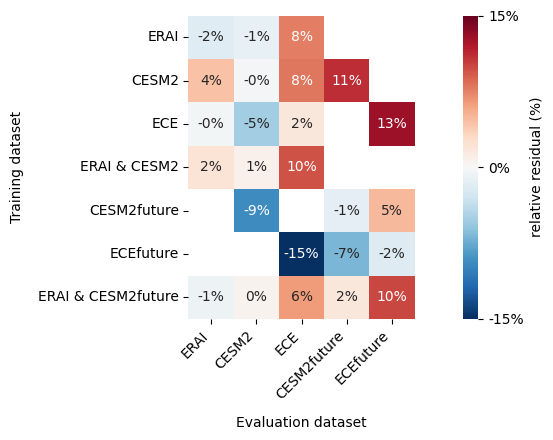

In [8]:
# Heatmap of relative residual

dff = df_rel['residual']

fig, ax = plt.subplots(figsize=(5.5, 4.5))

annot = dff.map(lambda x: "-" if pd.isna(x) or np.isclose(x, 0) else f"{x:.0%}")

sns.heatmap(
    dff,
    annot=annot,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-0.15,  
    vmax=0.15,
    mask=dff.isna(),
    cbar_kws={"label": "relative residual (%)", "extend": None, "pad": 0.15},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_xlabel("Evaluation dataset", labelpad=10)
ax.set_ylabel("Training dataset", labelpad=10)

cbar = ax.collections[0].colorbar
cbar.set_ticks([-0.15, 0, 0.15])
cbar.set_ticklabels(["-15%", "0%", "15%"])

plt.tight_layout()

pos = cbar.ax.get_position()

cbar.ax.set_position([
    pos.x0,
    pos.y0 - 0. ,      # lower
    pos.width,
    pos.height + 0.    # taller
])

plt.show()

## Tables for models with albedo

In [9]:
MODEL_SPECS = ['CESM2', 'CESM2future', 'ECEfuture']
DATA_SPECS = ['CESM2', 'CESM2future', 'ECEfuture']

BEST_ITERS = {'CESM2': 1,
              'CESM2future': 1,
              'ECEfuture': 5}


EVAL_SPECS = {k: DATA_SPECS for k in MODEL_SPECS}

In [10]:
scaling_factor = 1.796553703424 / 58391

scores = {model: {} for model in EVAL_SPECS}

for model_spec, data_specs in EVAL_SPECS.items():
    pred_dir = os.path.sep.join([base_dir, 'output', f'repeated_{model_spec}_modularNNEBMalbedo_log'])
    print(f'Model {model_spec}: {pred_dir}')
    for data_spec in data_specs:
        scores_file = os.path.sep.join([pred_dir, f'scores_per_year_{data_spec}.csv'])
        print(f'  Data {data_spec}: {scores_file}')
        try:
            df = pd.read_csv(scores_file, index_col=[0,1,2])
            df_best = df[df.index.get_level_values('iter')==BEST_ITERS[model_spec]]

            df_best.loc[:,'MAE_total'] = df_best['MAE'] * scaling_factor * 58391 * 365.25     # MAE converted to total Gt per year
            df_best.loc[:,'MAE_rel'] = df_best['MAE_total'] / df_best['true melt']
            
            scores[model_spec][data_spec] = df_best
        except:
            pass

Model CESM2: /home/eschlager/MeltEmulation/output/repeated_CESM2_modularNNEBMalbedo_log
  Data CESM2: /home/eschlager/MeltEmulation/output/repeated_CESM2_modularNNEBMalbedo_log/scores_per_year_CESM2.csv
  Data CESM2future: /home/eschlager/MeltEmulation/output/repeated_CESM2_modularNNEBMalbedo_log/scores_per_year_CESM2future.csv
  Data ECEfuture: /home/eschlager/MeltEmulation/output/repeated_CESM2_modularNNEBMalbedo_log/scores_per_year_ECEfuture.csv
Model CESM2future: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBMalbedo_log
  Data CESM2: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBMalbedo_log/scores_per_year_CESM2.csv


/tmp/ipykernel_1801513/3108514731.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best.loc[:,'MAE_total'] = df_best['MAE'] * scaling_factor * 58391 * 365.25     # MAE converted to total Gt per year
/tmp/ipykernel_1801513/3108514731.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best.loc[:,'MAE_rel'] = df_best['MAE_total'] / df_best['true melt']
/tmp/ipykernel_1801513/3108514731.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

  Data CESM2future: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBMalbedo_log/scores_per_year_CESM2future.csv
  Data ECEfuture: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBMalbedo_log/scores_per_year_ECEfuture.csv
Model ECEfuture: /home/eschlager/MeltEmulation/output/repeated_ECEfuture_modularNNEBMalbedo_log
  Data CESM2: /home/eschlager/MeltEmulation/output/repeated_ECEfuture_modularNNEBMalbedo_log/scores_per_year_CESM2.csv
  Data CESM2future: /home/eschlager/MeltEmulation/output/repeated_ECEfuture_modularNNEBMalbedo_log/scores_per_year_CESM2future.csv
  Data ECEfuture: /home/eschlager/MeltEmulation/output/repeated_ECEfuture_modularNNEBMalbedo_log/scores_per_year_ECEfuture.csv


/tmp/ipykernel_1801513/3108514731.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best.loc[:,'MAE_total'] = df_best['MAE'] * scaling_factor * 58391 * 365.25     # MAE converted to total Gt per year
/tmp/ipykernel_1801513/3108514731.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best.loc[:,'MAE_rel'] = df_best['MAE_total'] / df_best['true melt']
/tmp/ipykernel_1801513/3108514731.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [11]:
df_mean = {}
df_min = {}
df_max = {}
df_rel = {}

metrics = ['MAE', 'residual']

for score_name in metrics:
    
    df_mean[score_name] = pd.DataFrame({
        model: {
            dataset: sc[score_name].mean()
            for dataset, sc in datasets.items()
        }
        for model, datasets in scores.items()
    }).T

    df_min[score_name] = pd.DataFrame({
        model: {
            dataset: sc[score_name].min()
            for dataset, sc in datasets.items()
        }
        for model, datasets in scores.items()
    }).T

    df_max[score_name] = pd.DataFrame({
        model: {
            dataset: sc[score_name].max()
            for dataset, sc in datasets.items()
        }
        for model, datasets in scores.items()
    }).T

    df_rel[score_name] = pd.DataFrame({
            model: {
                dataset: sc[score_name+'_rel'].mean()
                for dataset, sc in datasets.items()
            }
            for model, datasets in scores.items()
        }).T

    print(score_name)
    display(df_mean[score_name].style.format('{:.2f}'))
    display(df_rel[score_name].style.format('{:.0%}'))

MAE


,CESM2,CESM2future,ECEfuture
CESM2,0.06,0.17,0.17
CESM2future,0.07,0.14,0.14
ECEfuture,0.08,0.16,0.13


,CESM2,CESM2future,ECEfuture
CESM2,4%,4%,4%
CESM2future,5%,3%,4%
ECEfuture,5%,4%,3%


residual


,CESM2,CESM2future,ECEfuture
CESM2,3.70,6.77,19.39
CESM2future,7.68,-9.19,-17.43
ECEfuture,19.00,21.56,9.93


,CESM2,CESM2future,ECEfuture
CESM2,0%,0%,1%
CESM2future,1%,-0%,-1%
ECEfuture,2%,1%,0%


In [12]:
# write tables for latex:

def make_latex_table(df_mean, df_rel, df_min, df_max):

    # best (lowest mean) in each column
    best = df_mean.eq(df_mean.min(axis=0), axis=1)

    rows = []

    for row in df_mean.index:

        cells = []

        for col in df_mean.columns:

            m = df_mean.loc[row, col]

            # skip NaNs
            if pd.isna(m):
                cells.append("")
                continue

            r = df_rel.loc[row, col]
            mn = df_min.loc[row, col]
            mx = df_max.loc[row, col]

            cell = (
                rf"\parbox[c]{{2cm}}{{"
                rf"{m:.2f} ({r*100:.0f}\%) \\ "
                rf"\footnotesize [{mn:.2f},{mx:.2f}]}}"
            )

            if row == col:
                cell = rf"\textbf{{{cell}}}"

            cells.append(cell)

        row_label = str(row).replace("&", r"\&")
        latex_row = f"& {row_label} & " + " & ".join(cells) + r" \\"
        rows.append(latex_row)

    return "\n".join(rows)

for score_name in ['MAE', 'residual']:
    latex = make_latex_table(
        df_mean=df_mean[score_name],
        df_rel=df_rel[score_name],
        df_min=df_min[score_name],
        df_max=df_max[score_name],
    )

    print(score_name)
    print(latex, '\n')

MAE
& CESM2 & \textbf{\parbox[c]{2cm}{0.06 (4\%) \\ \footnotesize [0.03,0.07]}} & \parbox[c]{2cm}{0.17 (4\%) \\ \footnotesize [0.12,0.22]} & \parbox[c]{2cm}{0.17 (4\%) \\ \footnotesize [0.13,0.24]} \\
& CESM2future & \parbox[c]{2cm}{0.07 (5\%) \\ \footnotesize [0.05,0.10]} & \textbf{\parbox[c]{2cm}{0.14 (3\%) \\ \footnotesize [0.11,0.17]}} & \parbox[c]{2cm}{0.14 (4\%) \\ \footnotesize [0.13,0.19]} \\
& ECEfuture & \parbox[c]{2cm}{0.08 (5\%) \\ \footnotesize [0.05,0.11]} & \parbox[c]{2cm}{0.16 (4\%) \\ \footnotesize [0.12,0.20]} & \textbf{\parbox[c]{2cm}{0.13 (3\%) \\ \footnotesize [0.11,0.17]}} \\ 

residual
& CESM2 & \textbf{\parbox[c]{2cm}{3.70 (0\%) \\ \footnotesize [-3.11,10.00]}} & \parbox[c]{2cm}{6.77 (0\%) \\ \footnotesize [-14.51,34.34]} & \parbox[c]{2cm}{19.39 (1\%) \\ \footnotesize [6.35,33.43]} \\
& CESM2future & \parbox[c]{2cm}{7.68 (1\%) \\ \footnotesize [-5.05,16.94]} & \textbf{\parbox[c]{2cm}{-9.19 (-0\%) \\ \footnotesize [-40.68,13.72]}} & \parbox[c]{2cm}{-17.43 (-1\%) 